In [1]:
from torchmetrics.classification import MultilabelAveragePrecision
from torch.utils.data import DataLoader
from datasets import load_dataset
from model import Tagger
from torch import Tensor
from utils import transform_test
import torch, dotenv, os
from loss import VPULoss
from utils import show_imgs, show_preds, confusion_matrix
from torchvision.transforms.functional import pil_to_tensor
import numpy as np, pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

In [2]:
dotenv.load_dotenv()
token = os.getenv('HF_TOKEN')

device = 'cuda'

model = Tagger().to(device)
model.load_state_dict(torch.load('outputs/Best-E9.pt')['model_state_dict'])

loss = VPULoss(1, 0)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [3]:
ds = load_dataset('Brambles/Ponies', token=token)

ds_train = ds['train']
ds_val = ds['validation']

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/31 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/59 [00:00<?, ?it/s]

In [4]:
to_predict = (
    'female', 'male',
    'unicorn', 'pegasus', 'earth pony', 'alicorn',
    'simple background', 'monochrome',
    'clothes', 'wings', 'horn', 'chest fluff', 'ear fluff', 'hat', 'jewelry', 'foal',
    'looking at you', 'smiling', 'open mouth', 'blushing', 'sitting', 'raised hoof', 'eyes closed',
    'twilight sparkle', 'fluttershy', 'rainbow dash', 'pinkie pie', 'rarity', 'applejack', 'princess celestia', 'princess luna',
    'socks', 'text', 'tongue out', 'lying down'
)

In [5]:
batch_size = 64

In [6]:
def transform(batch):
    return {
        'images': torch.stack([transform_test(img) for img in batch['image']]),
        'tags': torch.tensor(batch['tags'], dtype=torch.float32)
    }

In [7]:
dl_train = DataLoader(
    ds_train.with_transform(transform),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
)

dl_test = DataLoader(
    ds_val.with_transform(transform),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=2,
    persistent_workers=True,
)

In [8]:
def test(model):
    model.eval()
    all_logits = torch.zeros((len(ds_val), len(to_predict)))

    with torch.no_grad():
        for i, batch in enumerate(dl_test):
            X: Tensor = batch['images'].to(device)
            # y: Tensor = batch['tags'].to(device)

            logits = model(X)
            all_logits[i * batch_size : (i + 1) * batch_size] = logits

            print(f'\r{(i+1)*100/len(dl_test):.1f}%', end='')

        print()
        return all_logits.sigmoid()

In [9]:
f = MultilabelAveragePrecision(len(to_predict))

preds = test(model)
labels = torch.as_tensor(ds_val['tags'])

print(f'mAP: {f(preds, labels):.3f}')

100.0%
mAP: 0.718


In [10]:
def get_pos_doubts(n=5):
    pos_doubts = []

    for i, sample_preds in enumerate(preds):
        sample_preds = sample_preds.clone()
        positives = labels[i] == 1

        if positives.sum() == 0:
            continue

        sample_preds[~positives] = 2

        idx_min_conf = sample_preds.argmin()

                      # index              label            confidence
        pos_doubts.append((i, to_predict[idx_min_conf], sample_preds[idx_min_conf].item()))

    df = pd.DataFrame(pos_doubts, columns=['index', 'label', 'conf'])
    df.index = df['index']
    df.drop('index', axis=1, inplace=True)

    return df.sort_values('conf')[:n]

In [11]:
def show_test_imgs(test_ds_idx):
    n = len(test_ds_idx)
    fig, ax = plt.subplots(1, n, figsize=(n * 2, 2))
    plt.subplots_adjust(wspace=0, hspace=0)

    for i in range(n):
        ax[i].imshow(ds_val[test_ds_idx[i]]['image'])
        ax[i].axis(False)

,label,conf
index,,
662,socks,0.007086
1717,socks,0.007259
1335,princess luna,0.008129
2019,socks,0.009343
1910,male,0.009816
2243,socks,0.010060
1555,socks,0.010656
1272,applejack,0.010681
2048,socks,0.010721


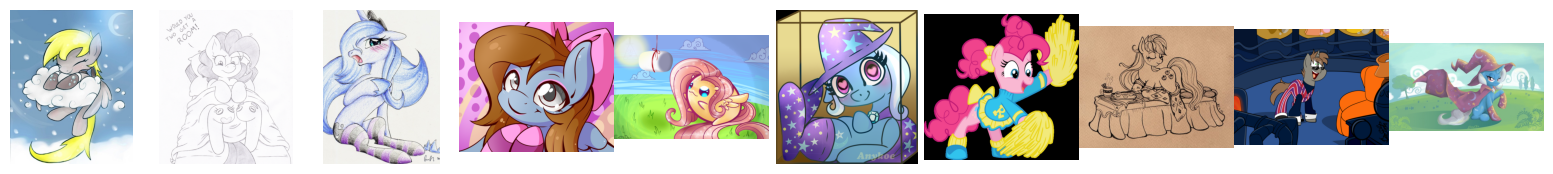

In [12]:
pos_doubts = get_pos_doubts(10)

show_test_imgs(pos_doubts.index)
pos_doubts

/tmp/ipykernel_34365/636046965.py:11: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)
/tmp/ipykernel_34365/636046965.py:11: RuntimeWarning: invalid value encountered in divide
  f1 = 2 * precision * recall / (precision + recall)


Macro f1: 0.726


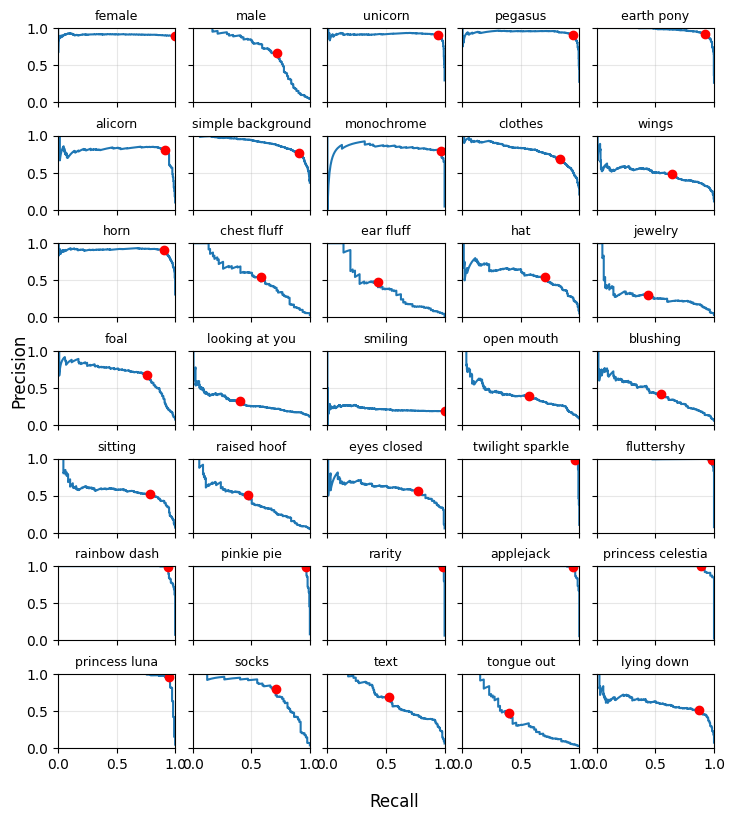

In [13]:
fig, ax = plt.subplots(7, 5, figsize=(8, 9))
ax: list[Axes] = ax.flatten()
f1s = np.zeros(len(to_predict))
thresholds = np.zeros_like(f1s)

for i, axis in enumerate(ax):
    y_true = labels[:, i].cpu().numpy()
    y_score = preds[:, i].cpu().numpy()

    precision, recall, threshold = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision * recall / (precision + recall)
    idx_best_f1 = np.nanargmax(f1)
    f1s[i] = np.nanmax(f1)
    thresholds[i] = threshold[idx_best_f1]

    axis.plot(recall, precision)
    axis.plot(recall[idx_best_f1], precision[idx_best_f1], 'ro')
    axis.set_title(to_predict[i], fontsize=9)
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.grid(alpha=.3)

for axis in ax:
    axis.label_outer()

fig.supxlabel('Recall')
fig.supylabel('Precision')

fig.subplots_adjust(
    left=0.08,
    bottom=0.08,
    wspace=0.15,
    hspace=0.45
)

print(f'Macro f1: {f1s.mean():.3f}')

In [14]:
pd.set_option('display.precision', 3)

final_preds = preds > torch.from_numpy(thresholds)
confusion_matrix(final_preds, labels, to_predict)

,tag,f1,precision,recall,tp,fp,tn,fn,count
27,rarity,0.984,0.988,0.981,158,2,2352,3,161
24,fluttershy,0.976,0.979,0.974,184,4,2322,5,189
26,pinkie pie,0.973,0.985,0.961,199,3,2305,8,207
23,twilight sparkle,0.972,0.981,0.963,257,5,2243,10,267
28,applejack,0.964,0.993,0.938,135,1,2370,9,144
25,rainbow dash,0.962,0.994,0.931,176,1,2325,13,189
30,princess luna,0.947,0.956,0.939,108,5,2395,7,115
0,female,0.944,0.894,1.000,2247,267,0,1,2248
29,princess celestia,0.932,1.000,0.873,55,0,2452,8,63
3,pegasus,0.927,0.912,0.942,652,63,1760,40,692


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7277657..2.6248863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.640001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.640001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6398644].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6394458].


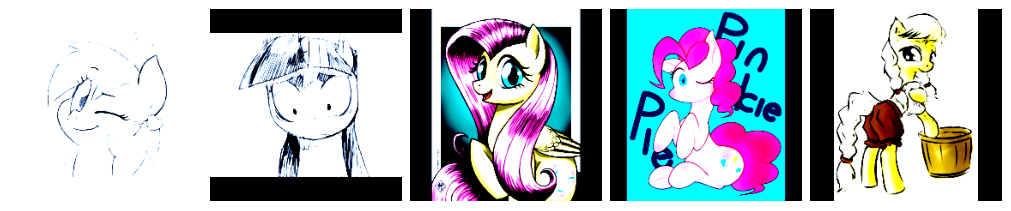

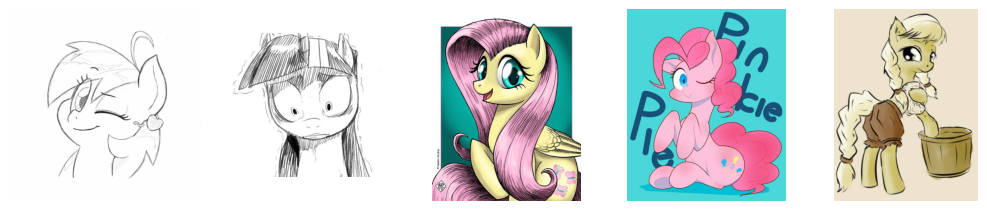

           female:  1.00  0
          smiling:  1.00  0
       monochrome:  1.00  1
simple background:  0.88  1
          pegasus:  0.61  0

       monochrome:  1.00  1
           female:  1.00  1
          smiling:  1.00  0
 twilight sparkle:  0.99  1
simple background:  0.59  0
   looking at you:  0.50  0

       fluttershy:  1.00  1
           female:  1.00  1
          smiling:  1.00  0
          pegasus:  1.00  1
       open mouth:  0.99  0
   looking at you:  0.82  1
      raised hoof:  0.72  0
            wings:  0.70  0

       pinkie pie:  1.00  1
           female:  1.00  1
       earth pony:  1.00  1
          smiling:  1.00  1
          sitting:  0.94  1
   looking at you:  0.68  1
simple background:  0.64  1

          clothes:  1.00  1
           female:  1.00  1
          smiling:  1.00  0
       earth pony:  0.97  1
simple background:  0.85  0


In [15]:
np.random.seed(0)

idx_obs = np.random.choice(len(ds_val), 5, False)
X, y = zip(*[(ds_val[i]['image'], ds_val[i]['tags']) for i in idx_obs])

batch = {
    'images': torch.stack([transform_test(x) for x in X]),
    'tags': torch.tensor(y)
}

X_t, y = batch['images'].to(device), batch['tags'].to(device)

with torch.no_grad():
    model.eval()

    logits = model(X_t).to(device)
    logits = logits.sigmoid()

    show_imgs(X_t.cpu())
    X = [image.convert('RGB') for image in X]
    show_imgs([pil_to_tensor(x) for x in X])

    show_preds(y.cpu(), logits.cpu().numpy(), to_predict)